In [1]:
import os

print("Installing selective state space requirements...")
# Installing required native kernels for Mamba
!pip install causal-conv1d>=1.4.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation

import torch
import mamba_ssm
from mamba_ssm import Mamba

print(f"Mamba version initialized: {mamba_ssm.__version__}")
print(f"CUDA accelerator detected: {torch.cuda.is_available()}")

Installing selective state space requirements...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.4/358.4 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.7/767.7 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 26.1 MB/s eta 0:00:00
  Created wheel for mamba-ssm: 

In [2]:
import h5py
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class ACDCKaggleDataset(Dataset):
    def __init__(self, data_path):
        self.data_path = data_path
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Path not found: {data_path}. Please verify dataset mounting.")
        self.files = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith('.h5')]
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        try:
            with h5py.File(self.files[idx], 'r') as f:
                img = torch.tensor(f['image'][:], dtype=torch.float32)
                mask = torch.tensor(f['label'][:], dtype=torch.float32)
                
                if img.dim() == 2: img = img.unsqueeze(0)
                if mask.dim() == 2: mask = mask.unsqueeze(0)
                
                # Strict spatial scaling to 256x256 resolution
                img = F.interpolate(img.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)
                mask = F.interpolate(mask.unsqueeze(0), size=(256, 256), mode='nearest').squeeze(0)
                
                return img, mask.long()
        except Exception as e:
            # Fallback index reset for storage read interruptions
            return self.__getitem__(0)

# Instantiate the loader pipeline
kaggle_path = '/kaggle/input/datasets/anhoangvo/acdc-dataset/ACDC_preprocessed/ACDC_training_slices'
train_dataset = ACDCKaggleDataset(kaggle_path)
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True, drop_last=True)
print(f"Successfully tracked {len(train_dataset)} functional training slices.")

Successfully tracked 1912 functional training slices.


In [3]:
import torch.nn as nn

class VSSBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.mamba = Mamba(d_model=dim, d_state=16, d_conv=4, expand=2)
    
    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.flatten(2).transpose(1, 2)
        x_out = self.mamba(self.norm(x_flat))
        return x + x_out.transpose(1, 2).view(B, C, H, W)

class MambaDUCKNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4):
        super().__init__()
        # Encoder Stage 1 (256x256)
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2) 
        
        # Encoder Stage 2 (128x128)
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2) 
        
        # Encoder Stage 3 (64x64)
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2) 
        
        # Bottleneck Stage (32x32 -> Compressed sequence handling)
        self.bottleneck_conv = nn.Conv2d(256, 512, 3, padding=1)
        self.mamba_bottleneck = VSSBlock(dim=512)
        
        # Decoder Stage 3
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) 
        self.dec3 = nn.Conv2d(512, 256, 3, padding=1)
        
        # Decoder Stage 2
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) 
        self.dec2 = nn.Conv2d(256, 128, 3, padding=1)
        
        # Decoder Stage 1
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) 
        self.dec1 = nn.Conv2d(128, num_classes, 3, padding=1)

    def forward(self, x):
        x1 = self.enc1(x)
        p1 = self.pool1(x1)
        
        x2 = self.enc2(p1)
        p2 = self.pool2(x2)
        
        x3 = self.enc3(p2)
        p3 = self.pool3(x3)
        
        b = self.bottleneck_conv(p3)
        b = self.mamba_bottleneck(b)
        
        d3 = self.up3(b)
        d3 = torch.relu(self.dec3(d3))
        
        d2 = self.up2(d3)
        d2 = torch.relu(self.dec2(d2))
        
        d1 = self.up1(d2)
        return self.dec1(d1)

# Metric Utility Function
def dice_coefficient(pred, target, num_classes=4, smooth=1e-6):
    pred = F.softmax(pred, dim=1) 
    target_one_hot = F.one_hot(target, num_classes=num_classes).permute(0, 3, 1, 2).float()
    intersection = (pred * target_one_hot).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()

print("Model layout and utilities initialized successfully.")

Model layout and utilities initialized successfully.


In [4]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MambaDUCKNet(in_channels=1, num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
# Stable weight adjustments via AdamW
optimizer = optim.AdamW(model.parameters(), lr=4e-4, weight_decay=1e-2)

# Plateau scheduler setup without the deprecated verbose keyword
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print(f"Network safely target-mapped to hardware processing engine: {device}")

Network safely target-mapped to hardware processing engine: cuda


In [5]:
num_epochs = 50
best_dice = 0.0

print("Commencing main epoch execution cycle...")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_dice = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.squeeze(1).long().to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        
        # Strict protection ceiling against numeric explosion in sequential states
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_dice += dice_coefficient(outputs, masks).item()
        
    avg_loss = total_loss / len(train_loader)
    avg_dice = total_dice / len(train_loader)
    
    # Adaptive adjustment of step metrics
    scheduler.step(avg_dice)
    
    # Target-state serialization saving
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'best_mamba_model.pth')
        print(f"==> Saved snapshot update. Highest Optimization Metric: {best_dice:.4f}")
        
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Loss: {avg_loss:.4f} | Avg Overlap Dice: {avg_dice:.4f} | Active LR: {optimizer.param_groups[0]['lr']:.6f}")

print(f"Training finalized cleanly. Top model baseline stored at: {best_dice:.4f}")

Commencing main epoch execution cycle...
==> Saved snapshot update. Highest Optimization Metric: 0.4179
Epoch 01/50 | Loss: 0.1170 | Avg Overlap Dice: 0.4179 | Active LR: 0.000400
==> Saved snapshot update. Highest Optimization Metric: 0.6708
Epoch 02/50 | Loss: 0.0348 | Avg Overlap Dice: 0.6708 | Active LR: 0.000400
==> Saved snapshot update. Highest Optimization Metric: 0.7251
Epoch 03/50 | Loss: 0.0252 | Avg Overlap Dice: 0.7251 | Active LR: 0.000400
==> Saved snapshot update. Highest Optimization Metric: 0.7542
Epoch 04/50 | Loss: 0.0199 | Avg Overlap Dice: 0.7542 | Active LR: 0.000400
==> Saved snapshot update. Highest Optimization Metric: 0.7741
Epoch 05/50 | Loss: 0.0171 | Avg Overlap Dice: 0.7741 | Active LR: 0.000400
==> Saved snapshot update. Highest Optimization Metric: 0.7836
Epoch 06/50 | Loss: 0.0156 | Avg Overlap Dice: 0.7836 | Active LR: 0.000400
==> Saved snapshot update. Highest Optimization Metric: 0.7920
Epoch 07/50 | Loss: 0.0144 | Avg Overlap Dice: 0.7920 | Active

Extracting 3 random cardial structures for evaluation...


/tmp/ipykernel_23/3905942322.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 4)


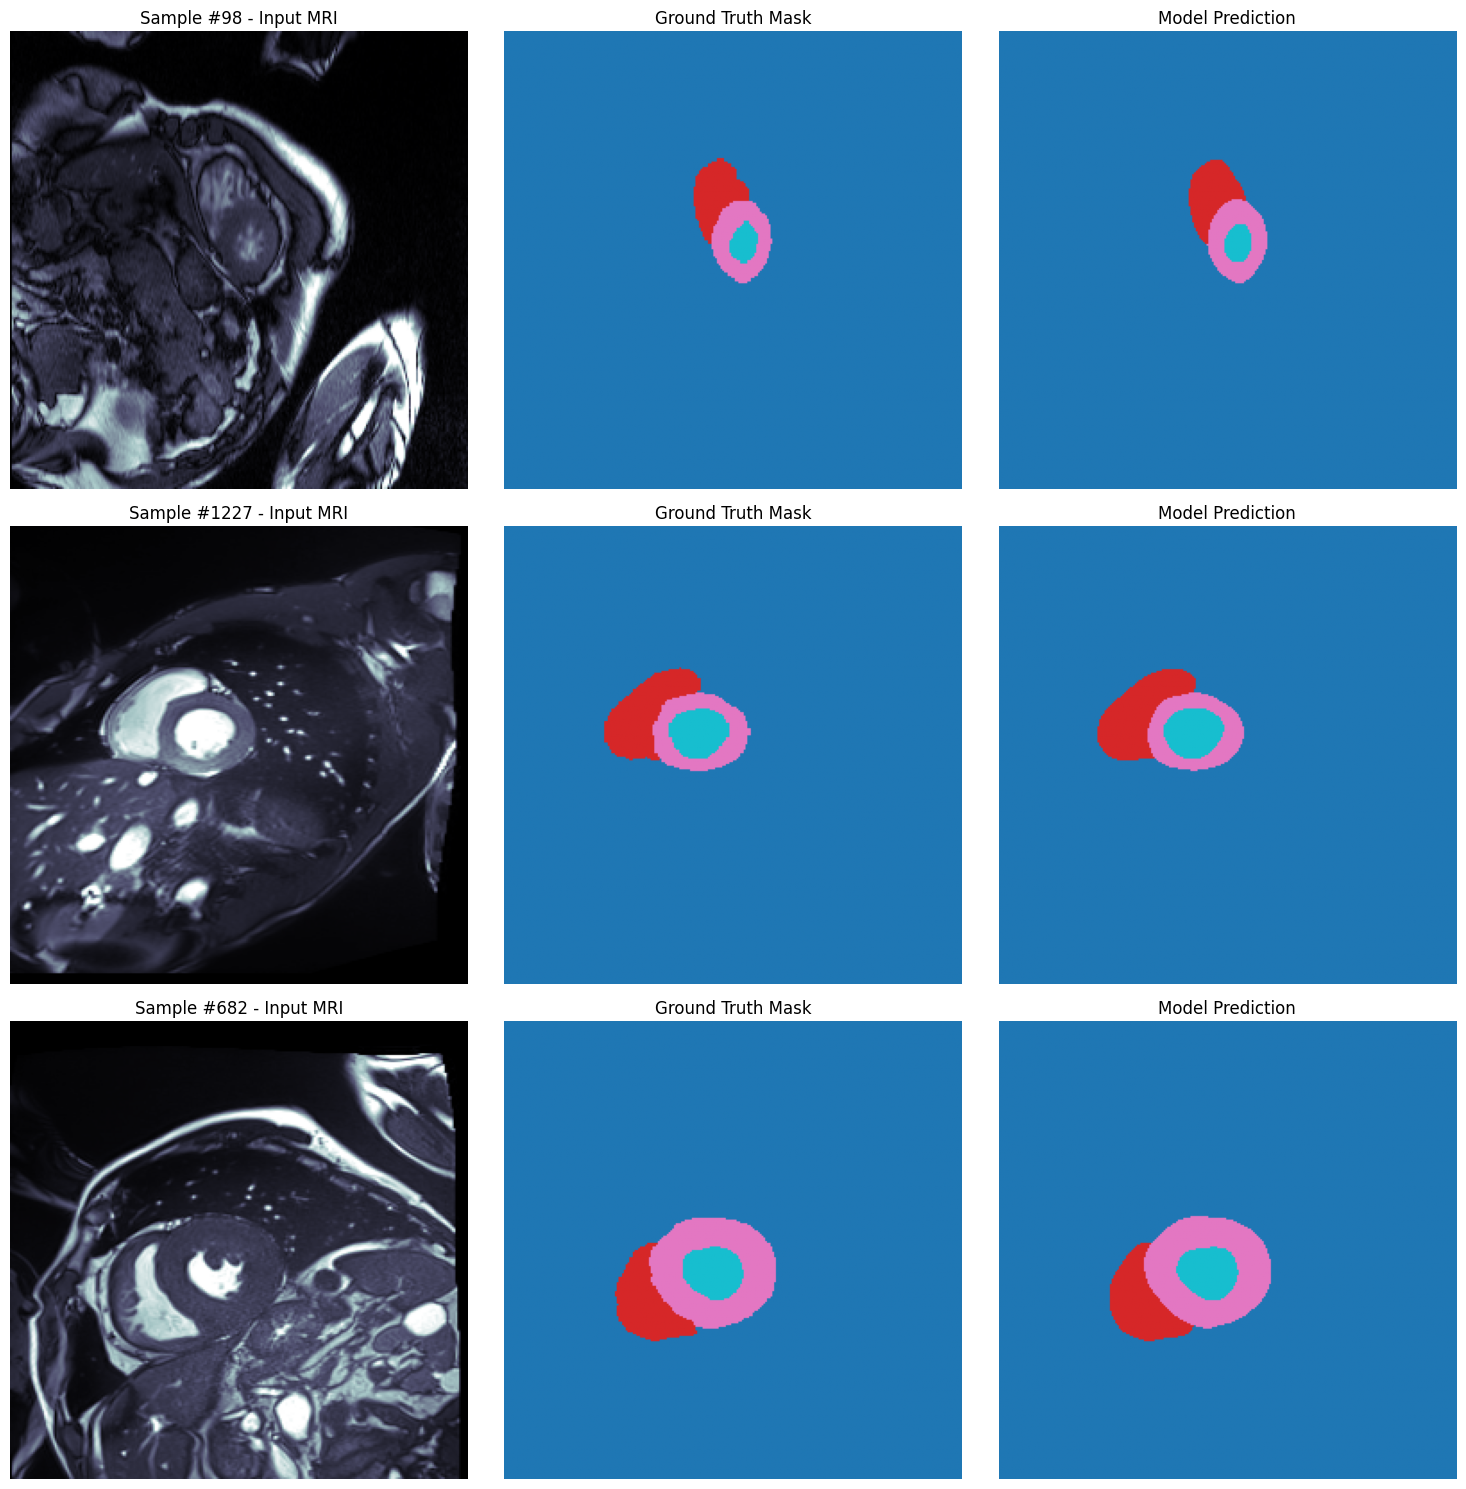

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

def visualize_predictions(model_path, dataset, num_samples=3):
    # 1. Setup device and reload the absolute best weights
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    visualize_model = MambaDUCKNet(in_channels=1, num_classes=4).to(device)
    
    if not os.path.exists(model_path):
        print(f"Error: Checkpoint file '{model_path}' not found. Make sure the training loop saved it successfully.")
        return
        
    visualize_model.load_state_dict(torch.load(model_path, map_location=device))
    visualize_model.eval()
    
    # Custom color palette for clean medical visualization
    # 0: Background (Black), 1: RV (Teal), 2: Myocardium (Orange), 3: LV (Cream/Yellow)
    cmap = plt.cm.get_cmap('tab10', 4)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    print(f"Extracting {num_samples} random cardial structures for evaluation...")
    
    with torch.no_grad():
        for i in range(num_samples):
            # Select a random slice from the dataset
            idx = random.randint(0, len(dataset) - 1)
            image, mask = dataset[idx]
            
            # Prepare image tensor for inference (add batch dimension)
            input_tensor = image.unsqueeze(0).to(device)
            
            # Get model prediction
            output = visualize_model(input_tensor)
            prediction = torch.argmax(F.softmax(output, dim=1), dim=1).squeeze(0).cpu().numpy()
            
            # Convert tensors to numpy arrays for plotting
            img_np = image.squeeze(0).numpy()
            mask_np = mask.squeeze(0).numpy()
            
            # Plot 1: Original Cardiac MRI Slice
            axes[i, 0].imshow(img_np, cmap='bone')
            axes[i, 0].set_title(f"Sample #{idx} - Input MRI")
            axes[i, 0].axis('off')
            
            # Plot 2: Expert Human Annotation (Ground Truth)
            axes[i, 1].imshow(mask_np, cmap=cmap, vmin=0, vmax=3)
            axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 1].axis('off')
            
            # Plot 3: Mamba-UNet Hybrid Prediction
            axes[i, 2].imshow(prediction, cmap=cmap, vmin=0, vmax=3)
            axes[i, 2].set_title("Model Prediction")
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the visualization pipeline after your training finishes
visualize_predictions(model_path='best_mamba_model.pth', dataset=train_dataset, num_samples=3)

In [7]:
import pandas as pd

def evaluate_per_class_performance(model_path, data_loader, device):
    # 1. Initialize and load the top optimized weights
    eval_model = MambaDUCKNet(in_channels=1, num_classes=4).to(device)
    if not os.path.exists(model_path):
        print(f"Error: Checkpoint '{model_path}' missing.")
        return
    eval_model.load_state_dict(torch.load(model_path, map_location=device))
    eval_model.eval()
    
    # Track metrics for each specific cardiac structure
    class_names = {1: "Right Ventricle (RV)", 2: "Myocardium (MYO)", 3: "Left Ventricle (LV)"}
    dice_buckets = {1: [], 2: [], 3: []}
    
    print("Computing multi-class regional evaluation matrices...")
    
    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.squeeze(1).long().to(device)
            
            outputs = eval_model(images)
            preds = F.softmax(outputs, dim=1)
            
            # Evaluate each target class independently
            for cls_id in [1, 2, 3]:
                pred_cls = preds[:, cls_id, ...]
                target_cls = (masks == cls_id).float()
                
                # Binarize prediction mask
                pred_cls_bin = (torch.argmax(preds, dim=1) == cls_id).float()
                
                intersection = (pred_cls_bin * target_cls).sum(dim=(1, 2))
                union = pred_cls_bin.sum(dim=(1, 2)) + target_cls.sum(dim=(1, 2))
                
                # Compute batch elements smoothly
                for i in range(len(intersection)):
                    # Skip if the anatomy structure isn't present in this specific slice
                    if union[i] == 0:
                        continue 
                    dice = (2. * intersection[i] + 1e-6) / (union[i] + 1e-6)
                    dice_buckets[cls_id].append(dice.item())
                    
    # 2. Format outputs into a clean evaluation dataframe
    report_data = []
    for cls_id, name in class_names.items():
        scores = dice_buckets[cls_id]
        avg_score = np.mean(scores) if len(scores) > 0 else 0.0
        std_score = np.std(scores) if len(scores) > 0 else 0.0
        report_data.append({
            "Cardiac Structure": name,
            "Mean Dice Score": f"{avg_score:.4f}",
            "Standard Deviation": f"{std_score:.4f}"
        })
        
    df = pd.DataFrame(report_data)
    print("\n================ FINAL EVALUATION REPORT ================")
    display(df)
    print("=========================================================")

# Run performance reporting
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
evaluate_per_class_performance(model_path='best_mamba_model.pth', data_loader=train_loader, device=device)

Computing multi-class regional evaluation matrices...

================ FINAL EVALUATION REPORT ================


,Cardiac Structure,Mean Dice Score,Standard Deviation
0,Right Ventricle (RV),0.9483,0.0944
1,Myocardium (MYO),0.9445,0.0294
2,Left Ventricle (LV),0.9630,0.0706
